In [177]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import torch.nn as nn
from tqdm.auto import trange

In [178]:
GROUNDTRUTH_RES = 64000
GROUNDTRUTH_KERNEL_RES = 4097
KERNEL_SIGMA = 300.0
NOISE_LEVEL = 1e-5#0.000005
LARGE_KERNEL_RES = 512
LARGE_RES =4000#round(GROUNDTRUTH_RES*(LARGE_KERNEL_RES/GROUNDTRUTH_KERNEL_RES))
SMALL_KERNEL_RES = 128
SMALL_RES =1000#round(GROUNDTRUTH_RES*(SMALL_KERNEL_RES/GROUNDTRUTH_KERNEL_RES))
TAU = 1
ALPHA = 1e-10
ITERATIONS = 5000
WRONG_FFT_SKIP = False

In [179]:
import matplotlib

matplotlib.rc("font", **{"family": "sans-serif", "weight": "normal", "size": 30})
matplotlib.rc("legend", **{"fontsize": 30})
matplotlib.rc("xtick.major", **{"size": 7, "width": 1.0})
matplotlib.rc("xtick.minor", **{"size": 5, "width": 1.0})
matplotlib.rc("ytick.major", **{"size": 7, "width": 1.0})
matplotlib.rc("ytick.minor", **{"size": 5, "width": 1.0})
matplotlib.rc("savefig", **{"dpi": 75, "pad_inches": 0.1})

torch.Size([4000])


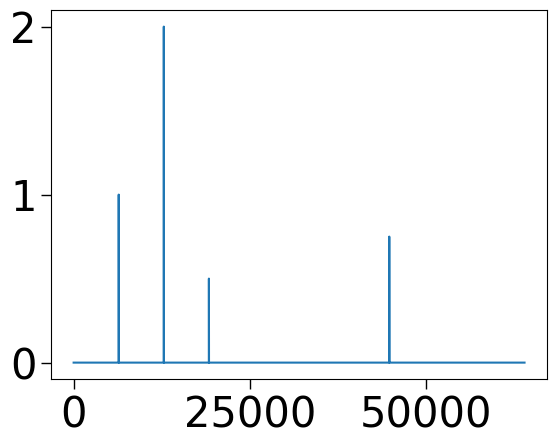

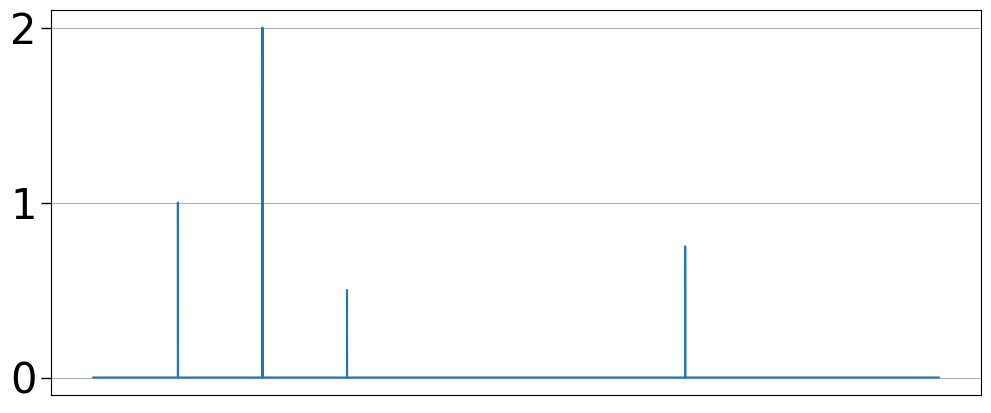

In [180]:
groundtruth_signal = torch.zeros(GROUNDTRUTH_RES)
groundtruth_signal[round(0.1*GROUNDTRUTH_RES)] = 1.0
groundtruth_signal[round(0.2*GROUNDTRUTH_RES)] = 2.0
groundtruth_signal[round(0.3*GROUNDTRUTH_RES)] = 0.5
groundtruth_signal[round(0.7*GROUNDTRUTH_RES)] = 0.75

groundtruth_largeres=groundtruth_signal[::(GROUNDTRUTH_RES//LARGE_RES)]

print(groundtruth_largeres.shape)

plt.plot(groundtruth_signal)


fig=plt.figure(figsize=(12,5))
#plt.title("Version 1")
plt.plot(groundtruth_signal,label='Ground truth')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
#plt.legend()
plt.savefig('1d_signal_gt.pdf')
pass

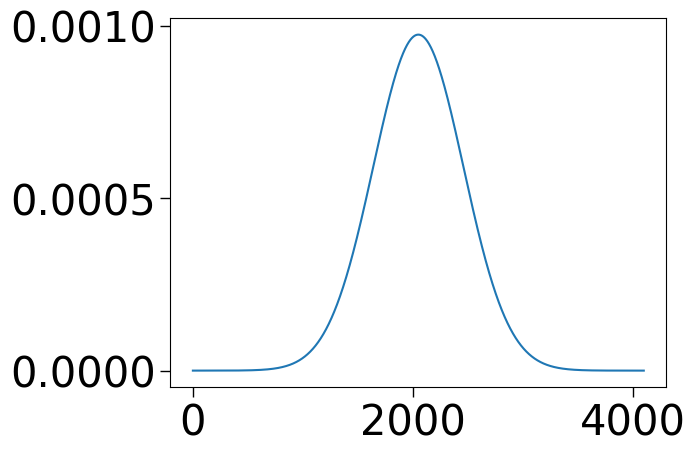

In [181]:
def gaussian_kernel(size, sigma):
    kernel = torch.exp(-0.5 * torch.linspace(-1500,1500,size)** 2 / sigma ** 2)
    return kernel / kernel.sum()

groundtruth_kernel = gaussian_kernel(GROUNDTRUTH_KERNEL_RES, KERNEL_SIGMA)

plt.plot(groundtruth_kernel)


pass

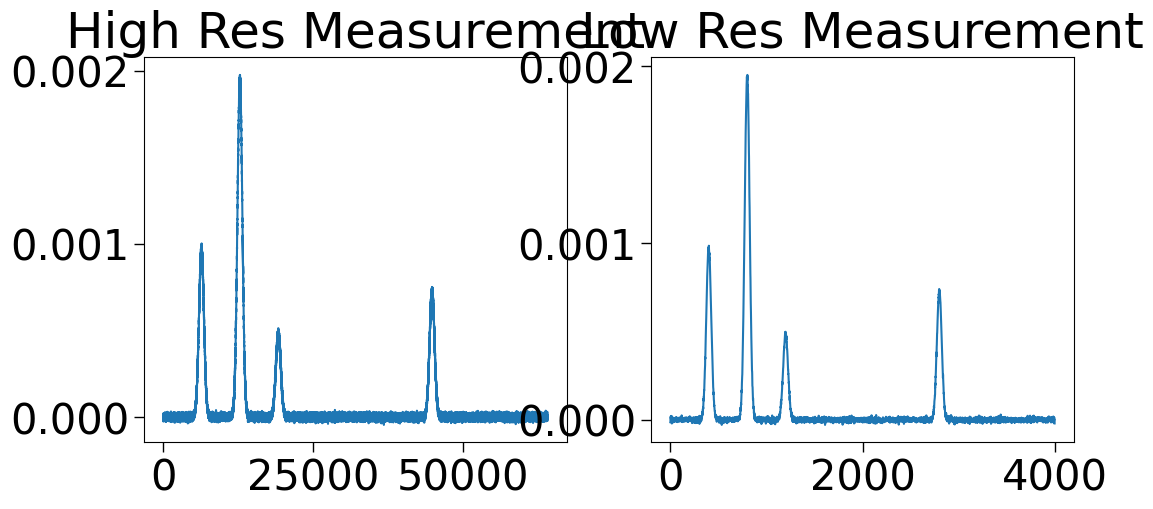

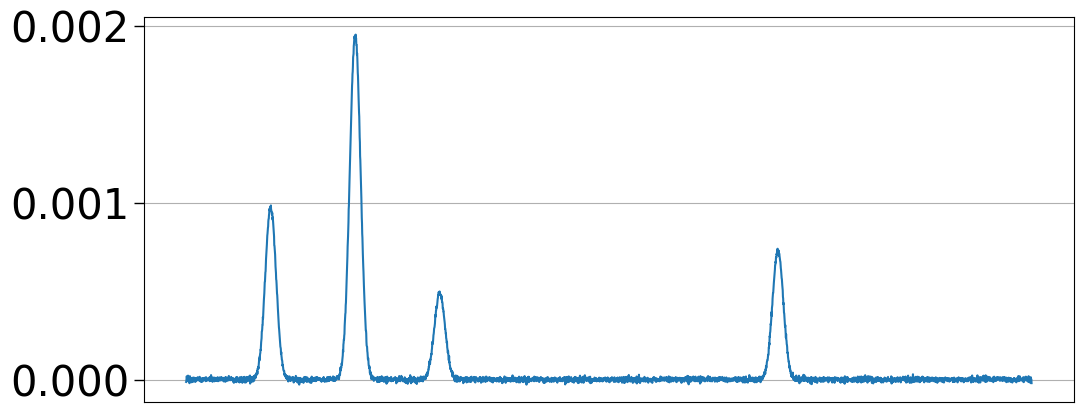

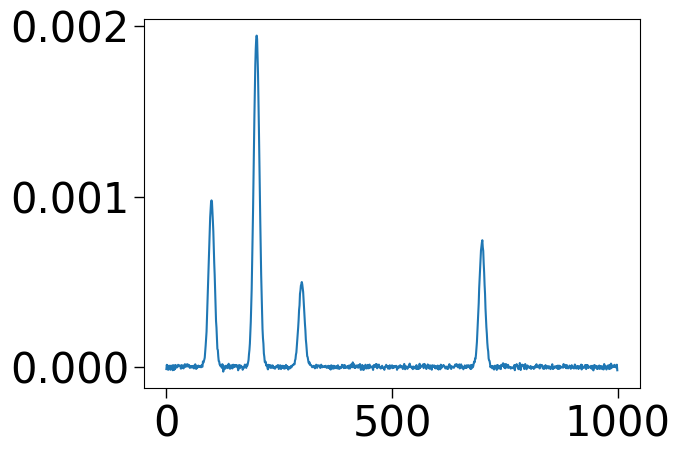

In [182]:
tmp = F.pad(groundtruth_signal[None,None], (GROUNDTRUTH_KERNEL_RES//2, GROUNDTRUTH_KERNEL_RES//2), mode="circular")[0,0]
measurement = F.conv1d(tmp[None,None], groundtruth_kernel[None,None])[0,0]
noisy_measurement = measurement + NOISE_LEVEL * torch.randn_like(measurement)
#large_noisy_measurement = F.interpolate(noisy_measurement[None,None], scale_factor=LARGE_KERNEL_RES/GROUNDTRUTH_KERNEL_RES, align_corners=True, mode="linear")[0,0]
large_noisy_measurement = F.interpolate(noisy_measurement[None,None], scale_factor=LARGE_RES/GROUNDTRUTH_RES, align_corners=True, mode="linear")[0,0]
small_noisy_measurement = F.interpolate(noisy_measurement[None,None], scale_factor=SMALL_RES/GROUNDTRUTH_RES, align_corners=True, mode="linear")[0,0]


plt.subplots(1,2, figsize=(12,5))
plt.subplot(1,2,1)
plt.title("High Res Measurement")
plt.plot(noisy_measurement)
plt.subplot(1,2,2)
plt.title("Low Res Measurement")
plt.plot(large_noisy_measurement)


fig=plt.figure(figsize=(12,5))
#plt.title("Version 1")
plt.plot(large_noisy_measurement,label='Noisy Data')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
#plt.legend()
plt.savefig('1d_signal_noisy.pdf')
pass
plt.show()
plt.plot(small_noisy_measurement)



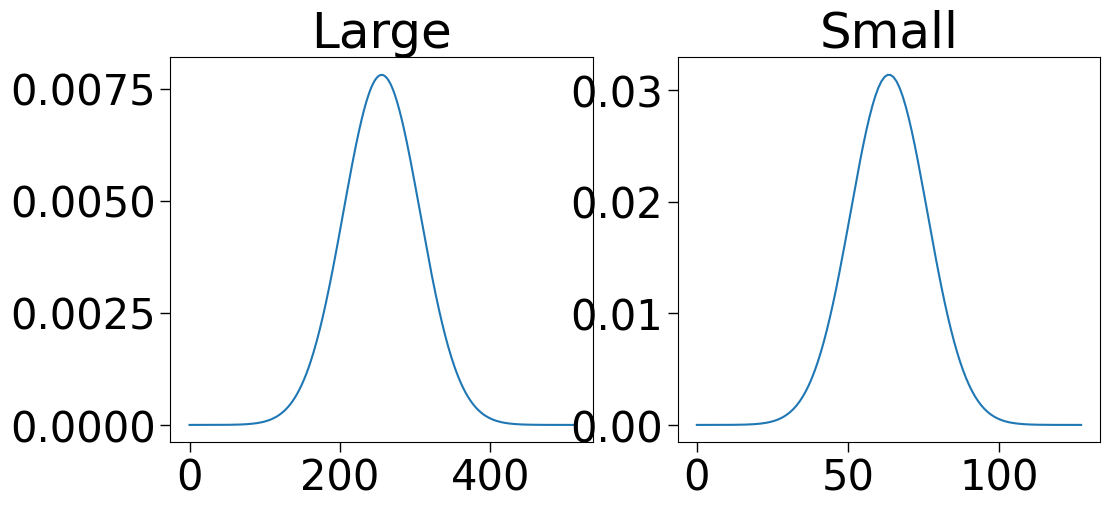

In [183]:
large_kernel = gaussian_kernel(LARGE_KERNEL_RES, sigma=KERNEL_SIGMA)
small_kernel = gaussian_kernel(SMALL_KERNEL_RES, sigma=KERNEL_SIGMA)

plt.subplots(1,2,figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Large")
plt.plot(large_kernel)
plt.subplot(1,2,2)
plt.title("Small")
plt.plot(small_kernel)
pass

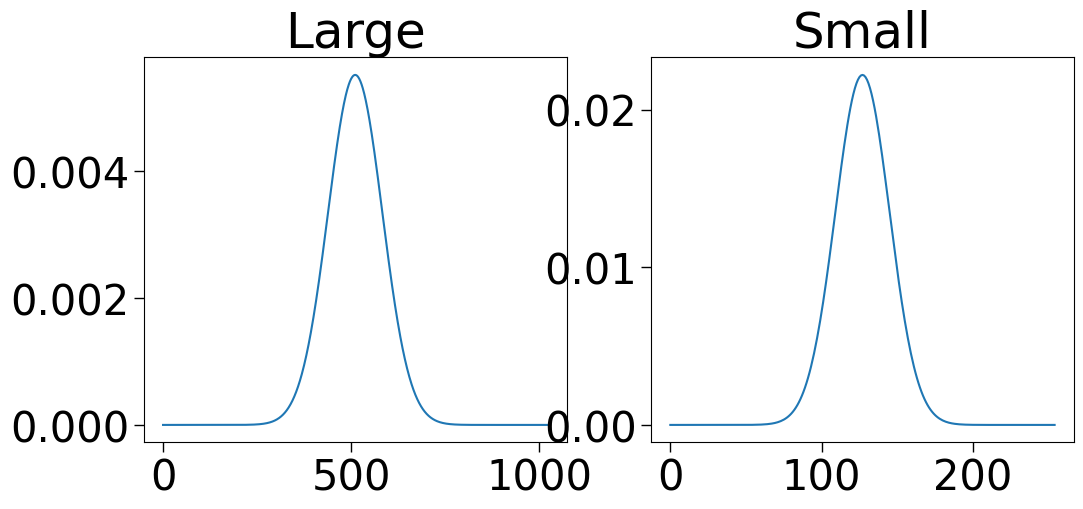

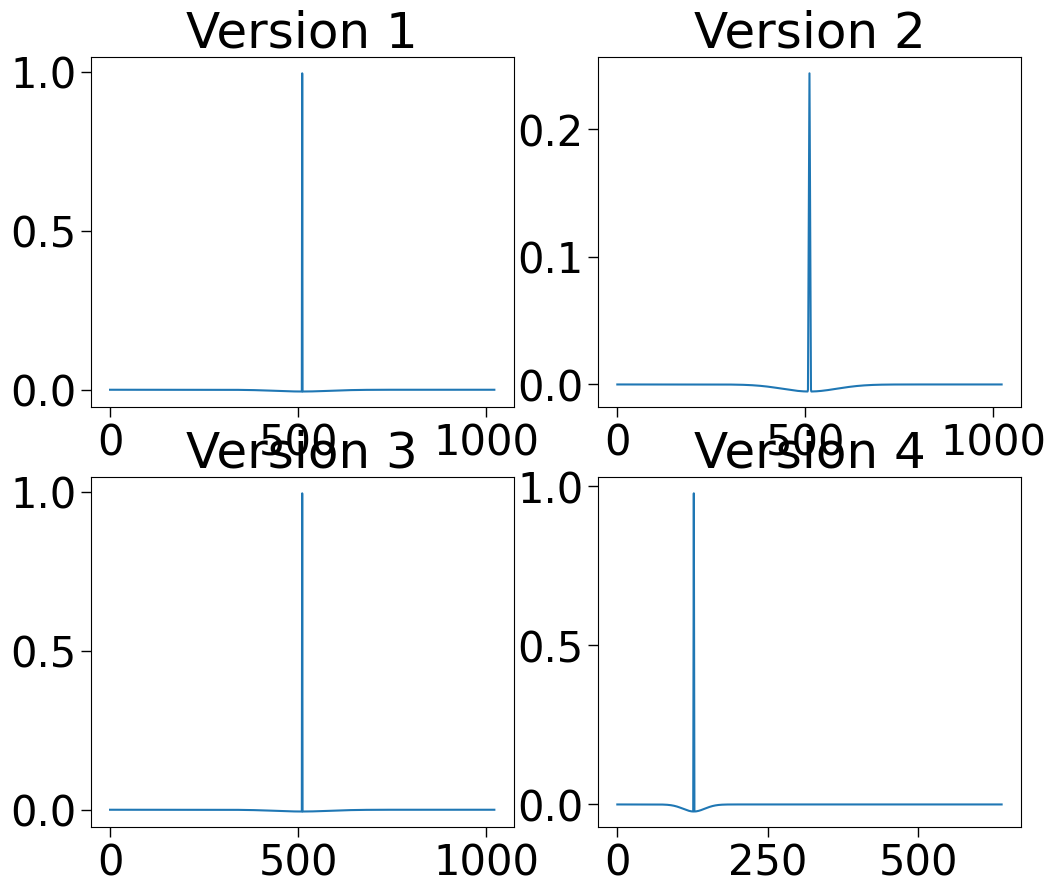

In [184]:
large_kTk = F.conv1d(large_kernel[None,None], large_kernel[None,None], padding=large_kernel.shape[0]-1)[0,0]
small_kTk = F.conv1d(small_kernel[None,None], small_kernel[None,None], padding=small_kernel.shape[0]-1)[0,0]

identity = torch.zeros_like(large_kTk)
identity[identity.shape[0]//2] = 1.0
kernel_v1 = identity - TAU*large_kTk

identity = torch.zeros_like(small_kTk)
identity[identity.shape[0]//2] = 1.0
tmp = identity-TAU*small_kTk
kernel_v2 = F.interpolate(tmp[None,None], scale_factor=large_kTk.shape[0]/small_kTk.shape[0], align_corners=True, mode="linear")[0,0]*small_kTk.shape[0]/large_kTk.shape[0]

tmp = F.interpolate(TAU*small_kTk[None,None], scale_factor=large_kTk.shape[0]/small_kTk.shape[0], align_corners=True, mode="linear")[0,0]*small_kTk.shape[0]/large_kTk.shape[0]
identity = torch.zeros(tmp.shape[0])
identity[identity.shape[0]//2] = 1.0
kernel_v3 = identity - tmp

identity = torch.zeros_like(small_kTk)
identity[identity.shape[0]//2] = 1.0
kernel_v4 = F.pad(identity-TAU*small_kTk, (0, LARGE_KERNEL_RES - SMALL_KERNEL_RES))

plt.subplots(1,2,figsize=(12,5))
plt.subplot(1,2,1)
plt.title("Large")
plt.plot(large_kTk)
plt.subplot(1,2,2)
plt.title("Small")
plt.plot(small_kTk)
plt.show()

plt.subplots(2,2,figsize=(12,10))
plt.subplot(2,2,1)
plt.title("Version 1")
plt.plot(kernel_v1)
plt.subplot(2,2,2)
plt.title("Version 2")
plt.plot(kernel_v2)
plt.subplot(2,2,3)
plt.title("Version 3")
plt.plot(kernel_v3)
plt.subplot(2,2,4)
plt.title("Version 4")
plt.plot(kernel_v4)
pass

In [185]:
from scipy import fft


def conv_fft_interp(signal, kernel, base_size):
    kernel_padded = torch.zeros(base_size, device=kernel.device)
    kernel_padded[:kernel.shape[0]] = kernel
    signal_fft = torch.fft.fft(signal, norm="forward")
    kernel_fft = torch.fft.fftshift(torch.fft.fft(kernel_padded, norm="forward"))
    diff = signal.shape[0] - kernel_fft.shape[0]
    kernel_fft = F.pad(kernel_fft, (diff // 2, diff - diff // 2), mode="constant", value=0)
    kernel_fft = torch.fft.ifftshift(kernel_fft)
    #print(kernel_fft.abs()*base_size)
    result_fft = kernel_fft * signal_fft
    kernel_interp = torch.fft.ifft(kernel_fft, norm="forward").real
    kernel_interp = kernel_interp[:round(kernel.shape[0]*signal.shape[0]/base_size)]
    result = torch.fft.ifft(result_fft, norm="forward").real *base_size#* signal.shape[0]
    result=torch.roll(result,-kernel_interp.shape[0]//2+2)
    return result , kernel_interp

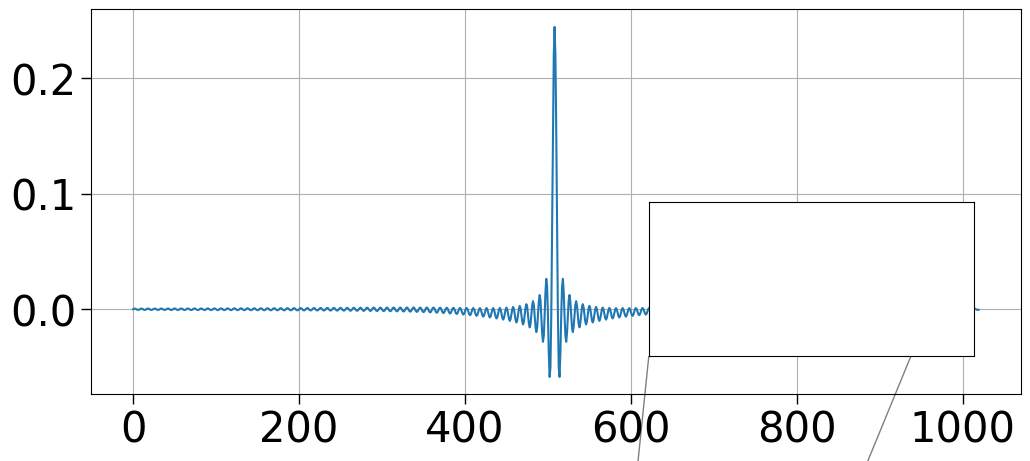

In [186]:

from matplotlib.pyplot import xlabel, ylim


identity = torch.zeros_like(small_kTk)
identity[identity.shape[0]//2] = 1.0
kernel = conv_fft_interp(large_noisy_measurement, identity-TAU*small_kTk, SMALL_RES)[1]

fig, ax1 = plt.subplots(figsize=(12,5))

# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.6, 0.1, 0.35, 0.4]

ax1.grid(True)
#ax1.get_xaxis().set_visible(False)
widespread=50
ax2 = ax1.inset_axes([left, bottom, width, height],
                     xlim=(kernel.shape[0]//2-widespread,kernel.shape[0]//2+widespread),
                     ylim=(-1.17,-0.7))
ax1.indicate_inset_zoom(ax2, edgecolor="black")



ax1.plot(kernel*SMALL_KERNEL_RES/LARGE_KERNEL_RES)
ax2.plot(kernel*SMALL_KERNEL_RES/LARGE_KERNEL_RES)
ax2.get_xaxis().set_visible(False)
ax2.get_yaxis().set_visible(False)
plt.savefig('fourier_1d_wrong.pdf')



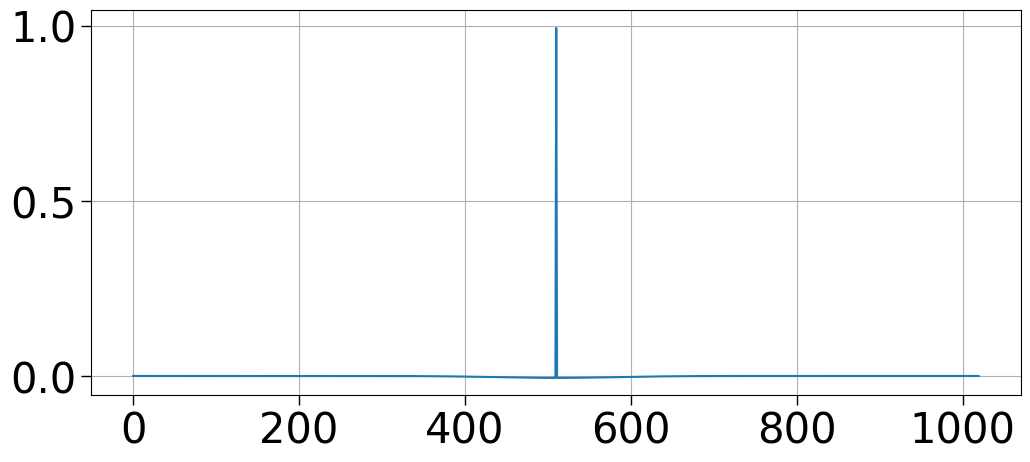

In [187]:

kernel = conv_fft_interp(large_noisy_measurement,TAU*small_kTk, SMALL_RES)[1]

identity = torch.zeros_like(kernel)
identity[identity.shape[0]//2] = 1.0

fig=plt.figure(figsize=(12,5))
#plt.gca().axes.get_xaxis().set_visible(False)
plt.plot((identity-torch.roll(kernel,2)*SMALL_KERNEL_RES/LARGE_KERNEL_RES))
plt.grid(True)
plt.savefig('fourier_1d_correct.pdf')


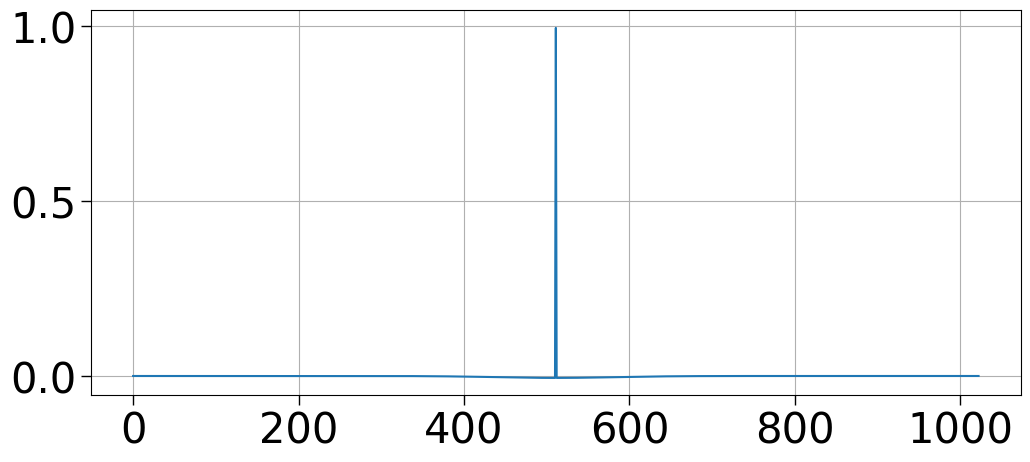

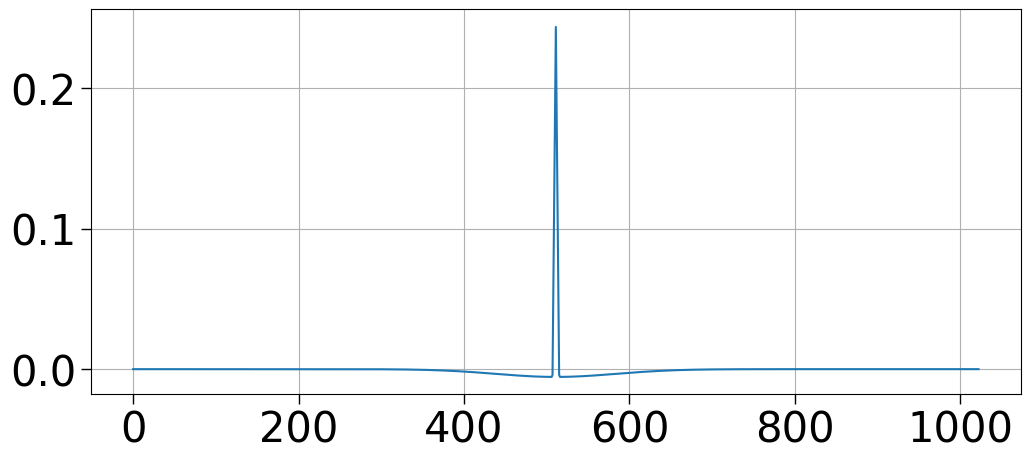

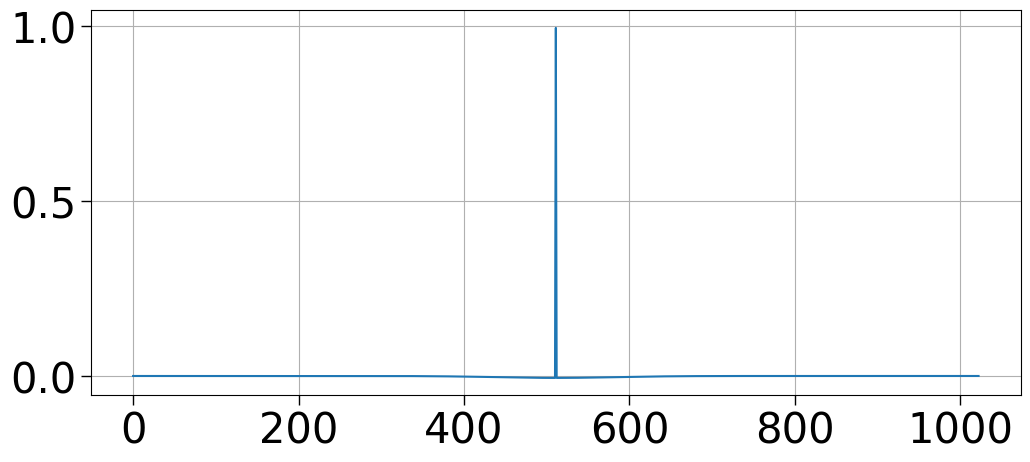

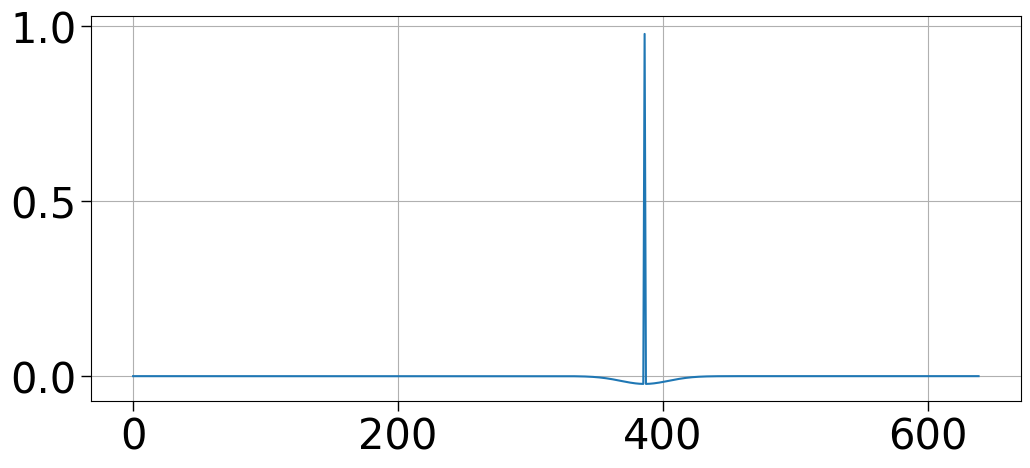

In [188]:
fig=plt.figure(figsize=(12,5))
#plt.gca().axes.get_xaxis().set_visible(False)
plt.plot(kernel_v1)
plt.grid(True)
plt.savefig('1d_true.pdf')



fig=plt.figure(figsize=(12,5))
#plt.gca().axes.get_xaxis().set_visible(False)
plt.plot(kernel_v2)
plt.grid(True)
plt.savefig('1d_wrong.pdf')


fig=plt.figure(figsize=(12,5))
#plt.gca().axes.get_xaxis().set_visible(False)
plt.plot(kernel_v3)
plt.grid(True)
plt.savefig('1d_correct.pdf')




fig=plt.figure(figsize=(12,5))
#plt.gca().axes.get_xaxis().set_visible(False)
#plt.plot(torch.roll(F.pad(kernel_v4[None,None], (((kernel_v1.shape[0]-kernel_v4.shape[0])//2),)*2, mode="constant")[0,0],(kernel_v1.shape[0]-kernel_v4.shape[0])//2))
plt.plot(torch.roll(kernel_v4,(kernel_v4.shape[0])//2-60))
plt.grid(True)
plt.savefig('1d_small.pdf')







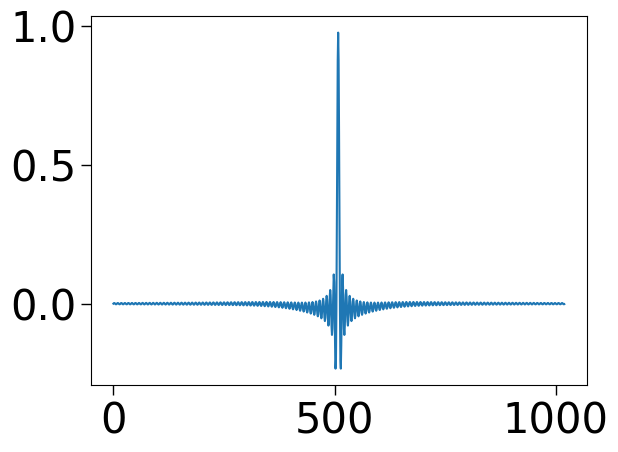

In [189]:
bad_recon = F.conv1d(large_noisy_measurement[None,None], kernel_v1.flip(0)[None,None], padding="same")[0,0]
identity = torch.zeros_like(small_kTk)
identity[identity.shape[0]//2] = 1.0
kernel_fft = conv_fft_interp(bad_recon, identity-TAU*small_kTk, SMALL_RES)[1]
plt.plot(kernel_fft)
pass

In [190]:
from torchmetrics.image import PeakSignalNoiseRatio as psnr
metric=psnr()

  0%|          | 0/5000 [00:00<?, ?it/s]

Spectral
torch.Size([4000]) 1000


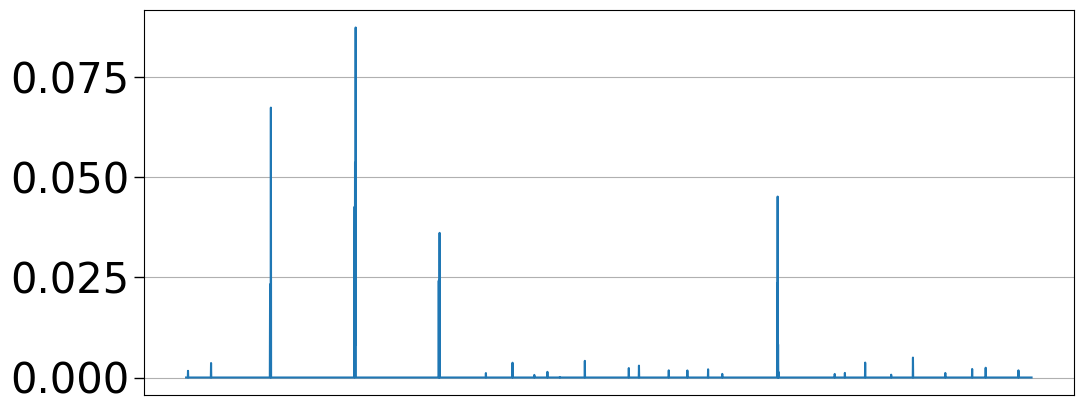

  0%|          | 0/5000 [00:00<?, ?it/s]

Large Kernel


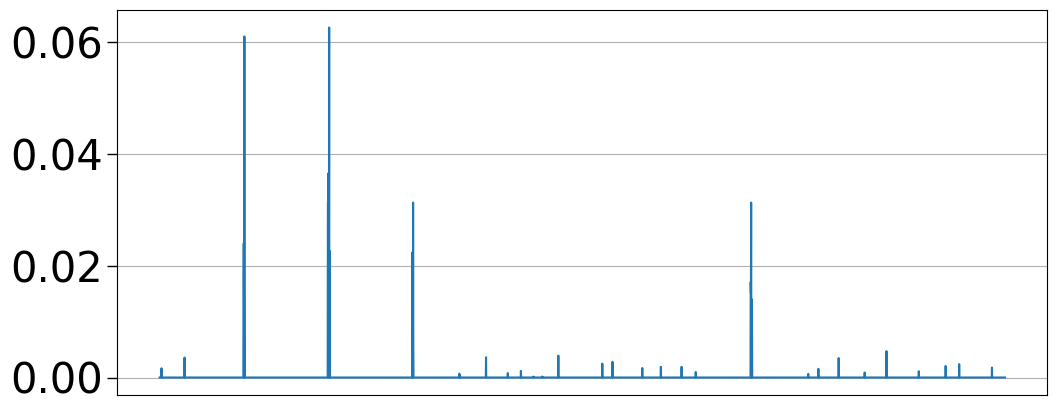

Interpolation wrong


  0%|          | 0/5000 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

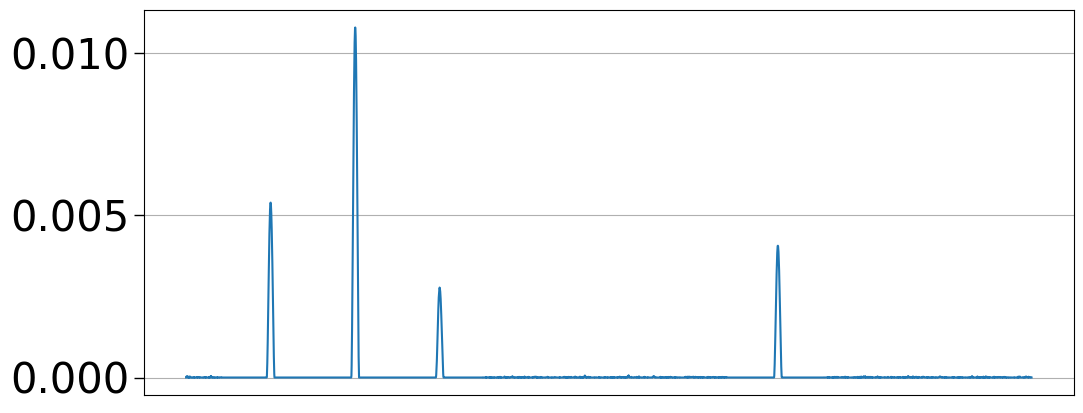

Interpolation correct


  0%|          | 0/5000 [00:00<?, ?it/s]

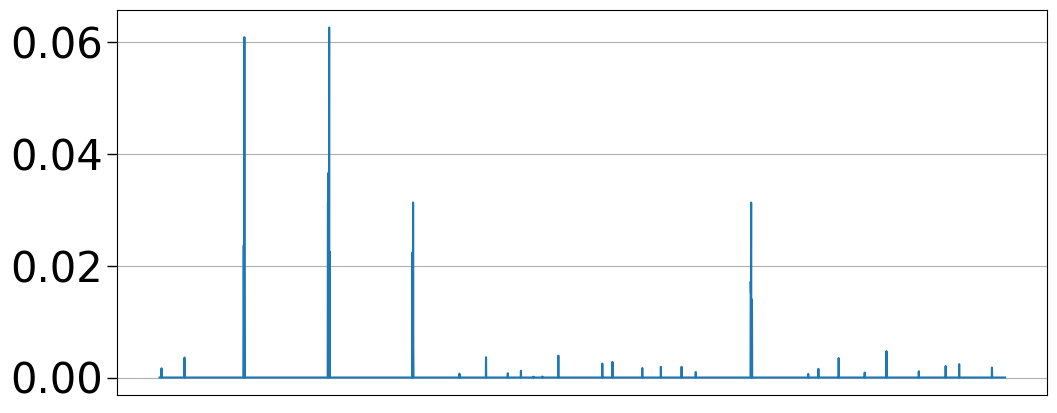

Small Kernel


  0%|          | 0/5000 [00:00<?, ?it/s]

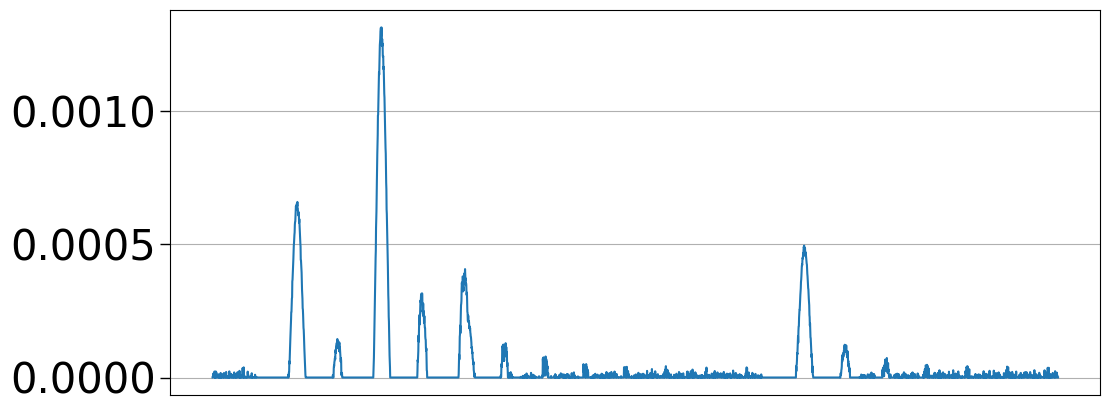

In [191]:
bad_recon = F.conv1d(large_noisy_measurement[None,None], kernel_v1.flip(0)[None,None], padding="same")[0,0]

kernel_v1 = kernel_v1.cuda()
kernel_v2 = kernel_v2.cuda()
kernel_v3 = kernel_v3.cuda()
kernel_v4 = kernel_v4.cuda()
bad_recon = bad_recon.cuda()
small_kTk = small_kTk.cuda()

recon = bad_recon.clone()


for _ in trange(ITERATIONS):
    if WRONG_FFT_SKIP:
        identity = torch.zeros_like(small_kTk, device=small_kTk.device)
        identity[identity.shape[0]//2] = 1.0
        recon = torch.relu(conv_fft_interp(recon, identity-TAU*small_kTk, SMALL_RES)[0]+TAU*bad_recon+ALPHA*TAU)
    else:
       recon = torch.relu(recon-conv_fft_interp(recon, TAU*small_kTk, SMALL_RES)[0]+TAU*bad_recon+ALPHA*TAU)

print('Spectral')
fig=plt.figure(figsize=(12,5))
print(recon.shape,SMALL_RES)
plt.plot(recon.cpu(), label='Reconstruction')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
plt.savefig('1d_signal_fourier.pdf')
plt.show()

recon_fourier=recon.clone()

recon = bad_recon.clone()
for _ in trange(ITERATIONS):
    recon = torch.relu(F.conv1d(F.pad(recon[None,None], (kernel_v1.shape[0]//2,)*2, mode="circular"), kernel_v1[None,None])[0,0]+TAU*bad_recon+ALPHA*TAU)
print('Large Kernel')

fig=plt.figure(figsize=(12,5))
plt.plot(recon.cpu(), label='Reconstruction')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
plt.savefig('1d_signal_v1.pdf')
plt.show()
fig=plt.figure()

print('Interpolation wrong')
recon = bad_recon.clone()
for _ in trange(ITERATIONS):
    recon = torch.relu(F.conv1d(F.pad(recon[None,None], (kernel_v2.shape[0]//2,)*2, mode="circular"), kernel_v2[None,None])[0,0]+TAU*bad_recon+ALPHA*TAU)
fig=plt.figure(figsize=(12,5))
plt.plot(recon.cpu(), label='Reconstruction')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
plt.savefig('1d_signal_v2.pdf')
plt.show()

print('Interpolation correct')
recon = bad_recon.clone()
for _ in trange(ITERATIONS):
    recon = torch.relu(F.conv1d(F.pad(recon[None,None], (kernel_v3.shape[0]//2,)*2, mode="circular"), kernel_v3[None,None])[0,0]+TAU*bad_recon+ALPHA*TAU)
fig=plt.figure(figsize=(12,5))
plt.plot(recon.cpu(), label='Reconstruction')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
plt.savefig('1d_signal_v3.pdf')
plt.show()

print('Small Kernel')
recon = bad_recon.clone()
for _ in trange(ITERATIONS):
    recon = torch.relu(F.conv1d(F.pad(recon[None,None], (kernel_v4.shape[0]//2,)*2, mode="circular"), kernel_v4[None,None])[0,0]+TAU*bad_recon+ALPHA*TAU)
fig=plt.figure(figsize=(12,5))
plt.plot(recon.cpu(), label='Reconstruction')
plt.gca().axes.get_xaxis().set_visible(False)
plt.grid(True)
plt.savefig('1d_signal_v4.pdf')
plt.show()



bad_recon = bad_recon.cpu()
recon = recon.cpu()
small_kTk = small_kTk.cpu()
kernel_v1 = kernel_v1.cpu()
kernel_v2 = kernel_v2.cpu()
kernel_v3 = kernel_v3.cpu()
kernel_v4 = kernel_v4.cpu()